In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from tqdm.auto import tqdm
from transformers import AutoModel
import torch
import torch.nn as nn
from transformers import AutoTokenizer
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


/home/thomas/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_PATH = "../data/train.csv"

df = pd.read_csv(TRAIN_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (57477, 9)

Columns:
['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


In [3]:
df["prompt_parsed"] = df["prompt"].apply(json.loads)
df["response_a_parsed"] = df["response_a"].apply(json.loads)
df["response_b_parsed"] = df["response_b"].apply(json.loads)

In [4]:
# print(df["prompt_parsed"].apply(len).value_counts().sort_index())
# print(df["response_a_parsed"].apply(len).value_counts().sort_index())
# print(df["response_b_parsed"].apply(len).value_counts().sort_index())
assert all(
    len(p) == len(a) == len(b)
    for p, a, b in zip(
        df["prompt_parsed"],
        df["response_a_parsed"],
        df["response_b_parsed"]
    )
)

print("All conversations are aligned!")

All conversations are aligned!


In [5]:
target_cols = [
    "winner_model_a",
    "winner_model_b",
    "winner_tie"
]

df["label"] = df[target_cols].values.argmax(axis=1)
print(df["label"].value_counts().sort_index())
print()
print((df["label"].value_counts(normalize=True).sort_index() * 100).round(2))

label
0    20064
1    19652
2    17761
Name: count, dtype: int64

label
0    34.91
1    34.19
2    30.90
Name: proportion, dtype: float64


In [6]:
def build_reward_input(row, response_key):
    conversation = []

    for prompt, response_a, response_b in zip(
        row["prompt_parsed"],
        row["response_a_parsed"],
        row["response_b_parsed"]
    ):
        if prompt is not None:
            conversation.append(f"User: {prompt}")

        response = response_a if response_key == "a" else response_b

        if response is not None:
            conversation.append(f"Assistant: {response}")

    return "\n".join(conversation)

In [45]:
def tokenize_head_tail(
    text,
    tokenizer,
    max_length=512,
    head_ratio=0.5
):
    # Tokenize without special tokens
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False
    )

    # Reserve space for [CLS] and [SEP]
    available_length = max_length - 2

    # --------------------------------
    # Short sequence: keep everything
    # --------------------------------

    if len(token_ids) <= available_length:

        input_ids = (
            [tokenizer.cls_token_id]
            + token_ids
            + [tokenizer.sep_token_id]
        )

    # --------------------------------
    # Long sequence: keep head + tail
    # --------------------------------

    else:

        head_length = int(
            available_length * head_ratio
        )

        tail_length = (
            available_length - head_length
        )

        head = token_ids[:head_length]
        tail = token_ids[-tail_length:]

        input_ids = (
            [tokenizer.cls_token_id]
            + head
            + tail
            + [tokenizer.sep_token_id]
        )

    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids)
    }

In [7]:
from sklearn.model_selection import train_test_split

df_small = df.iloc[:10000].copy()

train_df, val_df = train_test_split(
    df_small,
    test_size=0.1,
    random_state=42,
    stratify=df_small["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 9000
Validation: 1000


In [55]:
train_df["input_a"] = train_df.apply(
    lambda row: build_reward_input(row, "a"),
    axis=1
)

train_df["input_b"] = train_df.apply(
    lambda row: build_reward_input(row, "b"),
    axis=1
)

val_df["input_a"] = val_df.apply(
    lambda row: build_reward_input(row, "a"),
    axis=1
)

val_df["input_b"] = val_df.apply(
    lambda row: build_reward_input(row, "b"),
    axis=1
)

In [56]:
print(train_df[["input_a", "input_b", "label"]].iloc[0])

input_a    User: *That* kind of content without *that spe...
input_b    User: *That* kind of content without *that spe...
label                                                      2
Name: 1930, dtype: object


In [ ]:
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

backbone = AutoModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32
)

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 932.30it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok

In [58]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)

Using device: cuda


In [65]:
class RewardModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        
        self.backbone = backbone
        hidden_size = backbone.config.hidden_size
        self.attention_pool = nn.Linear(
            hidden_size,
            1
        )
        self.reward_head = nn.Linear(
            hidden_size,
            1
        )

        self.raw_tie_param = nn.Parameter(
            torch.tensor(0.5413)
        )

    def forward(self, input_ids, attention_mask):
        output = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = output.last_hidden_state

        attention_scores = self.attention_pool(
            hidden
        ).squeeze(-1)
        attention_scores = attention_scores.masked_fill(
            attention_mask == 0,
            -1e9
        )
        attention_weights = F.softmax(
            attention_scores,
            dim=1
        )
        pooled = torch.sum(
            hidden * attention_weights.unsqueeze(-1),
            dim=1
        )

        reward = self.reward_head(pooled)

        return reward.squeeze(-1)

    def get_tie_param(self):
        return F.softplus(self.raw_tie_param)

In [66]:
reward_model = RewardModel(backbone).to(device)

optimizer = torch.optim.AdamW(
    reward_model.parameters(),
    lr=2e-5
)

In [67]:
def preference_probabilities(reward_a, reward_b, tie_param=1.0):
    """
    Convert two reward scores into probabilities of:
    A wins, B wins, Tie
    """

    exp_a = torch.exp(reward_a)
    exp_b = torch.exp(reward_b)

    tie_term = (
        2 * tie_param *
        torch.exp((reward_a + reward_b) / 2)
    )

    denominator = exp_a + exp_b + tie_term

    prob_a = exp_a / denominator
    prob_b = exp_b / denominator
    prob_tie = tie_term / denominator

    return prob_a, prob_b, prob_tie

In [107]:
def tokenize_dataframe(df, tokenizer, max_length=512):
    enc_a = []
    enc_b = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Tokenizing"
    ):
        enc_a.append(
            tokenize_head_tail(
                row["input_a"],
                tokenizer,
                max_length
            )
        )

        enc_b.append(
            tokenize_head_tail(
                row["input_b"],
                tokenizer,
                max_length
            )
        )

    labels = df["label"].tolist()

    return enc_a, enc_b, labels

In [108]:
MAX_LENGTH = 512


class PreferenceDataset(Dataset):

    def __init__(self, enc_a, enc_b, labels):
        self.enc_a = enc_a
        self.enc_b = enc_b
        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.enc_a[idx],
            self.enc_b[idx],
            self.labels[idx]
        )

def collate_fn(batch):

    batch_a = [item[0] for item in batch]
    batch_b = [item[1] for item in batch]

    labels = torch.stack(
        [item[2] for item in batch]
    )

    enc_a = tokenizer.pad(
        batch_a,
        padding=True,
        return_tensors="pt"
    )

    enc_b = tokenizer.pad(
        batch_b,
        padding=True,
        return_tensors="pt"
    )

    enc_a.pop("token_type_ids", None)
    enc_b.pop("token_type_ids", None)

    return enc_a, enc_b, labels

In [109]:
train_dataset = PreferenceDataset(
    *tokenize_dataframe(train_df, tokenizer, MAX_LENGTH),
)

val_dataset = PreferenceDataset(
    *tokenize_dataframe(val_df, tokenizer, MAX_LENGTH),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

Tokenizing: 100%|██████████| 1000/1000 [00:01<00:00, 879.95it/s]


In [110]:
NUM_EPOCHS = 3

CHECKPOINT_DIR = "./models/reward_model"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
train_losses = []
train_steps = []

for epoch in range(NUM_EPOCHS):
    reward_model.train()

    running_loss = 0.0
    num_examples = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    for enc_a, enc_b, labels in progress_bar:

        enc_a = {k: v.to(device) for k, v in enc_a.items()}
        enc_b = {k: v.to(device) for k, v in enc_b.items()}
        labels = labels.to(device)

        optimizer.zero_grad()

        reward_a = reward_model(**enc_a)
        reward_b = reward_model(**enc_b)

        tie_param = reward_model.get_tie_param()

        prob_a, prob_b, prob_tie = preference_probabilities(
            reward_a,
            reward_b,
            tie_param
        )

        probabilities = torch.stack(
            [prob_a, prob_b, prob_tie],
            dim=1
        )

        true_probabilities = probabilities[
            torch.arange(labels.size(0), device=labels.device),
            labels
        ]

        loss = -torch.log(true_probabilities).mean()

        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_steps.append(len(train_losses))

        # Track loss
        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        num_examples += batch_size

        average_loss = running_loss / num_examples

        # Show current loss in tqdm
        progress_bar.set_postfix(
            loss=f"{average_loss:.4f}"
        )

    # Average training loss for the epoch
    train_loss = running_loss / num_examples

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} "
        f"- Train Loss: {train_loss:.4f}"
    )

    # Save checkpoint
    checkpoint_path = (
        f"{CHECKPOINT_DIR}/epoch_{epoch + 1}.pt"
    )

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": reward_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
        },
        checkpoint_path
    )

    print(f"Checkpoint saved to: {checkpoint_path}")

Epoch 1/3:   1%|▏         | 61/4500 [00:09<11:54,  6.21it/s, loss=0.5741] 


KeyboardInterrupt: 

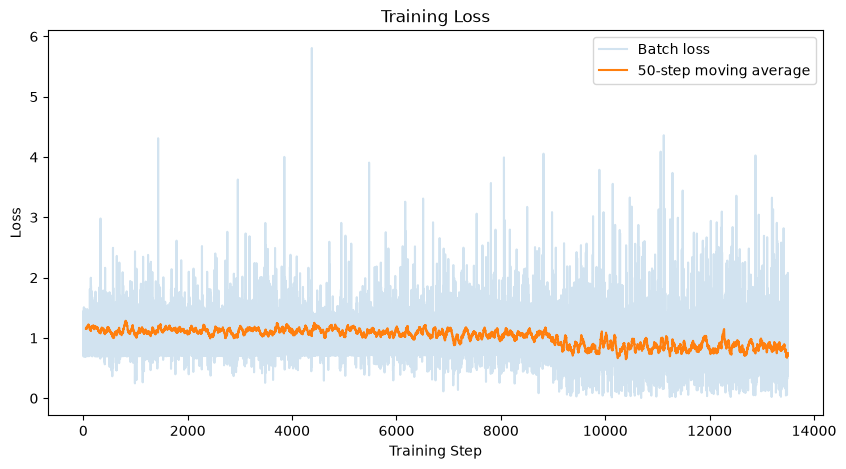

In [93]:
import numpy as np
import matplotlib.pyplot as plt

window = 50

smoothed_losses = np.convolve(
    train_losses,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    train_steps,
    train_losses,
    alpha=0.2,
    label="Batch loss"
)

plt.plot(
    train_steps[window - 1:],
    smoothed_losses,
    label=f"{window}-step moving average"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.show()

In [106]:
CHECKPOINT_DIR = "./models/reward_model"


def evaluate_checkpoint(checkpoint_path):

    # -----------------------------
    # Load checkpoint
    # -----------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    all_probabilities = []

    # Create a fresh model
    reward_model = RewardModel(backbone)

    reward_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    reward_model.to(device)
    reward_model.eval()

    # -----------------------------
    # Validation
    # -----------------------------

    total_loss = 0.0
    num_examples = 0
    correct = 0

    with torch.no_grad():
        progress_bar = tqdm( val_loader, desc="Validation" )

        for enc_a, enc_b, labels in progress_bar:

            enc_a = {
                k: v.to(device)
                for k, v in enc_a.items()
            }

            enc_b = {
                k: v.to(device)
                for k, v in enc_b.items()
            }

            labels = labels.to(device)

            # Get rewards
            reward_a = reward_model(**enc_a)
            reward_b = reward_model(**enc_b)

            # Learned tie parameter
            tie_param = reward_model.get_tie_param()

            # Davidson probabilities
            prob_a, prob_b, prob_tie = preference_probabilities(
                reward_a,
                reward_b,
                tie_param
            )

            probabilities = torch.stack(
                [prob_a, prob_b, prob_tie],
                dim=1
            )

            all_probabilities.append(
                probabilities.cpu()
            )

            # Probability assigned to correct class
            true_probabilities = probabilities[
                torch.arange(
                    labels.size(0),
                    device=labels.device
                ),
                labels
            ]

            # Log loss
            loss = -torch.log(
                true_probabilities
            ).mean()

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            num_examples += batch_size

            # Predictions
            predictions = probabilities.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

    # -----------------------------
    # Final metrics
    # -----------------------------

    all_probabilities = torch.cat(
        all_probabilities,
        dim=0
    )

    val_loss = total_loss / num_examples
    val_accuracy = correct / num_examples

    return {
        "epoch": checkpoint["epoch"],
        "train_loss": checkpoint["train_loss"],
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "tie_param": tie_param.item(),
        "probabilities": all_probabilities
    }


# =====================================
# Evaluate every checkpoint
# =====================================

results = []

checkpoint_files = sorted(
    [
        f for f in os.listdir(CHECKPOINT_DIR)
        if f.endswith(".pt")
    ],
    key=lambda x: int(
        x.split("_")[1].split(".")[0]
    )
)

for filename in checkpoint_files:

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        filename
    )

    result = evaluate_checkpoint(
        checkpoint_path
    )

    results.append(result)

    print(
        f"Epoch {result['epoch']}: "
        f"Train Loss = {result['train_loss']:.4f}, "
        f"Val Loss = {result['val_loss']:.4f}, "
        f"Val Accuracy = {result['val_accuracy']:.4f}, "
        f"Tie = {result['tie_param']:.4f}"
    )

# result = evaluate_checkpoint("./models/reward_model/epoch_3.pt")

Validation: 100%|██████████| 500/500 [00:22<00:00, 22.63it/s]


Epoch 1: Train Loss = 1.1213, Val Loss = 1.1415, Val Accuracy = 0.3090, Tie = 0.9744


Validation: 100%|██████████| 500/500 [00:23<00:00, 21.27it/s]


Epoch 2: Train Loss = 1.0748, Val Loss = 1.2009, Val Accuracy = 0.4490, Tie = 0.9519


Validation: 100%|██████████| 500/500 [00:23<00:00, 21.20it/s]

Epoch 3: Train Loss = 0.8572, Val Loss = 1.3727, Val Accuracy = 0.4540, Tie = 0.9433


In [104]:
for result in results:
    print(
        f"Epoch {result['epoch']}: "
        f"Train Loss = {result['train_loss']:.4f}, "
        f"Val Loss = {result['val_loss']:.4f}, "
        f"Val Accuracy = {result['val_accuracy']:.4f}, "
        f"Tie = {result['tie_param']:.4f}"
    )

# probabilities = results["probabilities"]
# # print(true_probabilities)
# max_confidence = probabilities.max(dim=1).values
# print(probabilities)

Epoch 3: Train Loss = 0.8572, Val Loss = 1.0728, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0494, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0533, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0575, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0614, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0647, Val Accuracy = 0.4540, Tie = 0.9433
Epoch 3: Train Loss = 0.8572, Val Loss = 1.0740, Val Accuracy = 0.4540, Tie = 0.9433


In [33]:
print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

label
0    0.350333
1    0.340778
2    0.308889
Name: proportion, dtype: float64


In [34]:
print(
    val_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)

label
0    0.350
1    0.341
2    0.309
Name: proportion, dtype: float64
